In [ ]:
!pip install emoji

In [ ]:
import pandas as pd
df = pd.read_csv('/content/2024B4PS0991P_TechAI.csv')
df.head()

,TEXT,POSITIVE,NEGATIVE,FRUSTRATION,CHILL GUY,HUMOROUS
0,That was slick bro 🔥,1,0,0,0,0
1,Bro this adda session was mad fun 😎,1,0,0,0,0
2,We crushed that quiz fr 💯,1,0,0,0,0
3,Mess pizza tonight was a W 🍕,1,0,0,0,0
4,"Lab report done, vibe check passed ✨",1,0,0,0,0


In [ ]:
import re
import emoji

# Function to convert emojis to text tokens
def emoji_to_text(text):
    return emoji.demojize(text, delimiters=(" ", " "))

# Function to clean text
def clean_text(text):
    text = str(text).lower()  # lowercase
    text = emoji_to_text(text)  # convert emojis to text tokens
    text = re.sub(r'[^\w\s]', '', text)  # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

# Apply cleaning on TEXT column
df["cleaned_text"] = df["TEXT"].apply(clean_text)

# Show cleaned text samples
print(df[["TEXT", "cleaned_text"]].head())


                                   TEXT  \
0                  That was slick bro 🔥   
1   Bro this adda session was mad fun 😎   
2             We crushed that quiz fr 💯   
3          Mess pizza tonight was a W 🍕   
4  Lab report done, vibe check passed ✨   

                                        cleaned_text  
0                            that was slick bro fire  
1  bro this adda session was mad fun smiling_face...  
2             we crushed that quiz fr hundred_points  
3                   mess pizza tonight was a w pizza  
4         lab report done vibe check passed sparkles  


In [ ]:
# Tokenize by splitting on whitespace
df["tokens"] = df["cleaned_text"].apply(lambda x: x.split())

# View tokenized results
print(df[["cleaned_text", "tokens"]].head())


                                        cleaned_text  \
0                            that was slick bro fire   
1  bro this adda session was mad fun smiling_face...   
2             we crushed that quiz fr hundred_points   
3                   mess pizza tonight was a w pizza   
4         lab report done vibe check passed sparkles   

                                              tokens  
0                      [that, was, slick, bro, fire]  
1  [bro, this, adda, session, was, mad, fun, smil...  
2      [we, crushed, that, quiz, fr, hundred_points]  
3           [mess, pizza, tonight, was, a, w, pizza]  
4  [lab, report, done, vibe, check, passed, spark...  


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 5000  # You can increase this for larger vocab

# Initialize Keras tokenizer, use <OOV> token for unknown words
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')

# Fit tokenizer on cleaned text
tokenizer.fit_on_texts(df['cleaned_text'])

# Convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

# Show example sequence
print(sequences[:5])




[[18, 5, 226, 4, 33], [4, 267, 734, 80, 5, 268, 176, 109, 2, 6, 127], [110, 735, 18, 86, 50, 72, 68], [7, 99, 408, 5, 10, 128, 99], [11, 129, 736, 155, 540, 737, 94]]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 20  # Max sequence length you want

# Pad sequences (post padding & truncating)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Check padded sequences
print(X[:5])


[[ 18   5 226   4  33   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  4 267 734  80   5 268 176 109   2   6 127   0   0   0   0   0   0   0
    0   0]
 [110 735  18  86  50  72  68   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [  7  99 408   5  10 128  99   0   0   0   0   0   0   0   0   0   0   0
    0   0]
 [ 11 129 736 155 540 737  94   0   0   0   0   0   0   0   0   0   0   0
    0   0]]


In [ ]:
import numpy as np

# List of sentiment columns
label_cols = ["POSITIVE", "NEGATIVE", "FRUSTRATION", "CHILL GUY", "HUMOROUS"]

# Convert those columns into a list of 0/1 ints per row
df['label'] = df[label_cols].values.tolist()

# Convert to numpy array for model training
y = np.array(df['label'].tolist())

# Show example labels
print(y[:5])


[[1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]
 [1 0 0 0 0]]


In [ ]:
from sklearn.model_selection import train_test_split

# Split into train + temp(test+val 20%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)

# Split temp into validation + test (10% each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)}, Validation size: {len(X_val)}, Test size: {len(X_test)}")


Train size: 800, Validation size: 100, Test size: 100


In [ ]:
X_train[:3]

array([[  4,  18, 275,  13, 111, 200, 424,   2,   6, 159,  38, 160,   0,
          0,   0,   0,   0,   0,   0,   0],
       [ 45, 373, 673,   3, 178, 628,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0],
       [  4, 374, 144,   9,   3, 118,  61,  56,   3, 515,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0]], dtype=int32)

In [ ]:
y_train[:3]

array([[1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0]])

In [ ]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved as tokenizer.pkl")


Tokenizer saved as tokenizer.pkl


In [ ]:
print(X_train.shape, y_train.shape)

(800, 20) (800, 5)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Parameters
VOCAB_SIZE = 5000
EMBEDDING_DIM = 100
HIDDEN_DIM = 64
OUTPUT_DIM = 5
PAD_IDX = 0
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 9e-4

# Define layers
embedding = nn.Embedding(VOCAB_SIZE, EMBEDDING_DIM, padding_idx=PAD_IDX)
conv = nn.Conv1d(EMBEDDING_DIM, 128, 3)
pool = nn.MaxPool1d(2)
lstm = nn.LSTM(128, HIDDEN_DIM, bidirectional=True, batch_first=True)
dropout = nn.Dropout(0.5)
fc = nn.Linear(HIDDEN_DIM * 2, OUTPUT_DIM)
sigmoid = nn.Sigmoid()

# Loss and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(list(embedding.parameters()) + list(conv.parameters()) +
                       list(lstm.parameters()) + list(fc.parameters()) + list(dropout.parameters()),
                       lr= LEARNING_RATE)

# Prepare data tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# Training loop
for epoch in range(EPOCHS):
    embedding.train()
    conv.train()
    lstm.train()
    dropout.train()
    fc.train()

    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()

        embedded = embedding(X_batch)
        embedded = embedded.permute(0, 2, 1)  # (batch, embed_dim, seq_len)
        conv_out = conv(embedded)
        pooled = pool(conv_out)
        pooled = pooled.permute(0, 2, 1)  # (batch, seq_len, channels)

        lstm_out, (hidden, cell) = lstm(pooled)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        dropped = dropout(hidden_cat)
        output = fc(dropped)
        output = sigmoid(output)

        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")


Epoch 1, Loss: 0.5630
Epoch 2, Loss: 0.4825
Epoch 3, Loss: 0.4158
Epoch 4, Loss: 0.3323
Epoch 5, Loss: 0.2467
Epoch 6, Loss: 0.1816
Epoch 7, Loss: 0.1311
Epoch 8, Loss: 0.0965
Epoch 9, Loss: 0.0749
Epoch 10, Loss: 0.0639
Epoch 11, Loss: 0.0536
Epoch 12, Loss: 0.0385
Epoch 13, Loss: 0.0335
Epoch 14, Loss: 0.0273
Epoch 15, Loss: 0.0278
Epoch 16, Loss: 0.0223
Epoch 17, Loss: 0.0216
Epoch 18, Loss: 0.0167
Epoch 19, Loss: 0.0166
Epoch 20, Loss: 0.0177
Epoch 21, Loss: 0.0170
Epoch 22, Loss: 0.0150
Epoch 23, Loss: 0.0140
Epoch 24, Loss: 0.0124
Epoch 25, Loss: 0.0121
Epoch 26, Loss: 0.0103
Epoch 27, Loss: 0.0112
Epoch 28, Loss: 0.0100
Epoch 29, Loss: 0.0087
Epoch 30, Loss: 0.0074
Epoch 31, Loss: 0.0102
Epoch 32, Loss: 0.0087
Epoch 33, Loss: 0.0099
Epoch 34, Loss: 0.0103
Epoch 35, Loss: 0.0093
Epoch 36, Loss: 0.0089
Epoch 37, Loss: 0.0062
Epoch 38, Loss: 0.0087
Epoch 39, Loss: 0.0082
Epoch 40, Loss: 0.0065
Epoch 41, Loss: 0.0072
Epoch 42, Loss: 0.0067
Epoch 43, Loss: 0.0079
Epoch 44, Loss: 0.00

Confusion Matrix for class 0:
[[82  4]
 [ 1 13]]


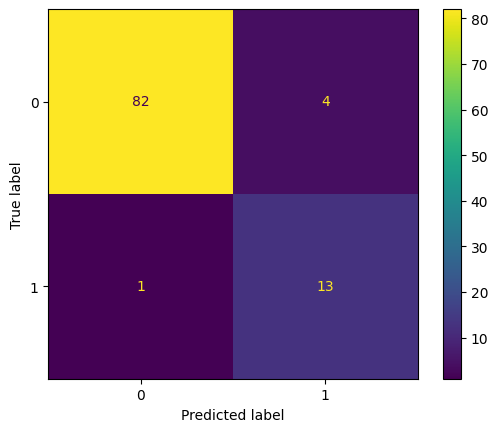

Confusion Matrix for class 1:
[[73  8]
 [13  6]]


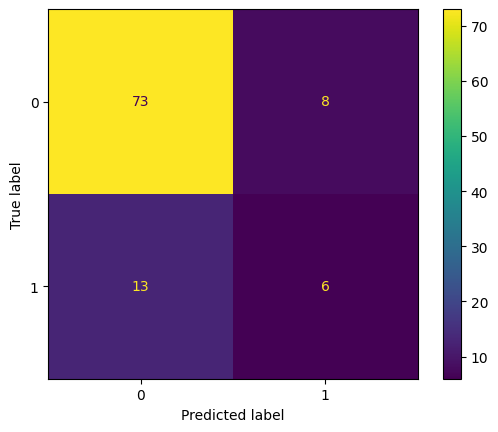

Confusion Matrix for class 2:
[[70  5]
 [ 7 18]]


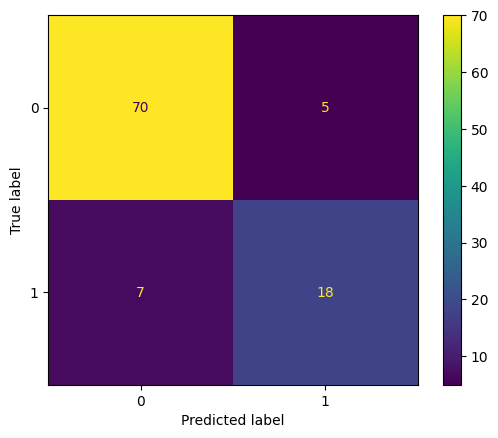

Confusion Matrix for class 3:
[[78  4]
 [ 3 15]]


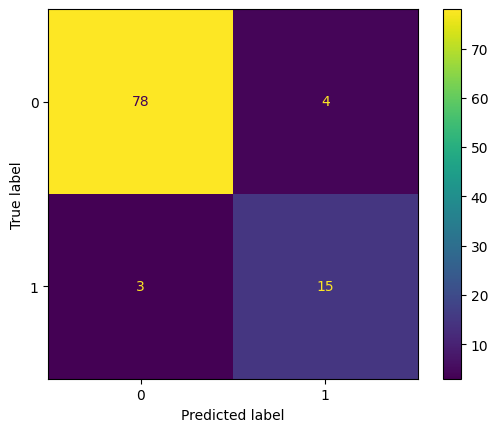

Confusion Matrix for class 4:
[[73  3]
 [11 13]]


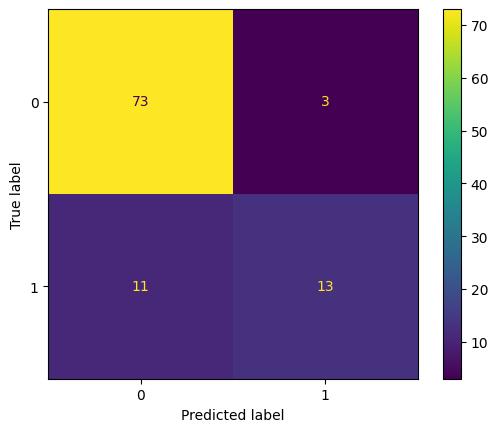

Precision: [0.76470588 0.42857143 0.7826087  0.78947368 0.8125    ]
Recall: [0.92857143 0.31578947 0.72       0.83333333 0.54166667]
F1-score: [0.83870968 0.36363636 0.75       0.81081081 0.65      ]

Validation Accuracy: 88.20%


In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prepare validation data loader similar to train_loader
X_val_tensor = torch.tensor(X_val, dtype=torch.long)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Set all layers to eval mode
embedding.eval()
conv.eval()
pool.eval()
lstm.eval()
dropout.eval()
fc.eval()
sigmoid.eval()

val_preds = []
val_targets = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        embedded = embedding(X_batch)
        embedded = embedded.permute(0, 2, 1)
        conv_out = conv(embedded)
        pooled = pool(conv_out)
        pooled = pooled.permute(0, 2, 1)

        lstm_out, (hidden, cell) = lstm(pooled)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        dropped = dropout(hidden_cat)
        output = fc(dropped)
        output = sigmoid(output)

        preds = (output > 0.5).int()  # Threshold sigmoid for binary output

        val_preds.append(preds.cpu().numpy())
        val_targets.append(y_batch.cpu().numpy())

val_preds = np.vstack(val_preds)
val_targets = np.vstack(val_targets)

# Add confusion matrix per class before precision/recall/f1
num_classes = val_targets.shape[1]

for i in range(num_classes):
    cm = confusion_matrix(val_targets[:, i], val_preds[:, i])
    print(f"Confusion Matrix for class {i}:")
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(val_targets, val_preds, average=None)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}\n")
accuracy = np.mean(val_preds == val_targets)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")


Confusion Matrix for class 0:
[[74  7]
 [ 4 15]]


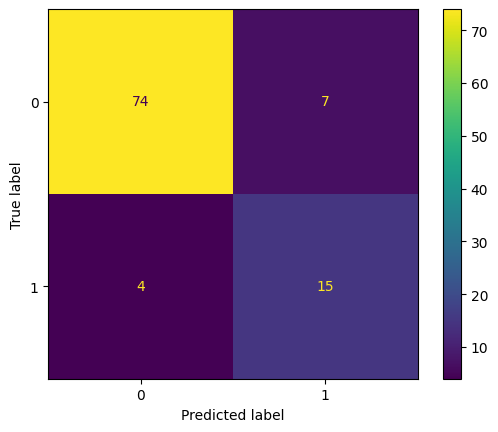

Confusion Matrix for class 1:
[[69  2]
 [12 17]]


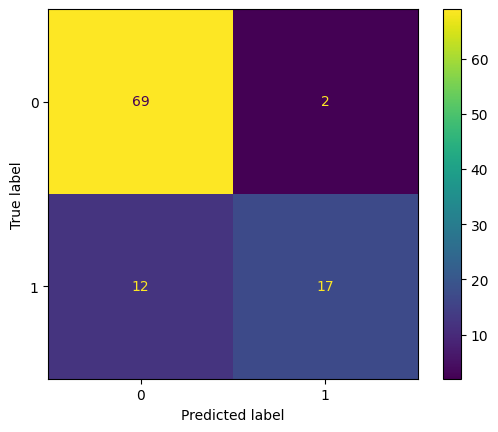

Confusion Matrix for class 2:
[[85  3]
 [ 3  9]]


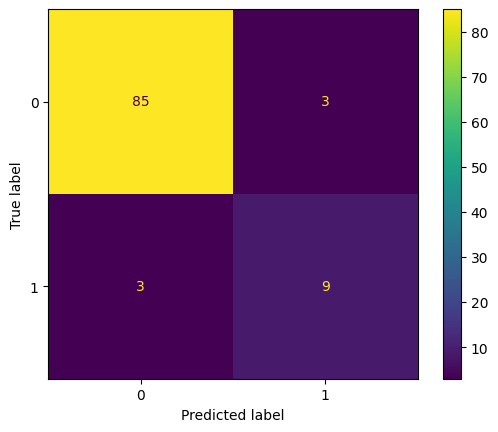

Confusion Matrix for class 3:
[[78  2]
 [ 6 14]]


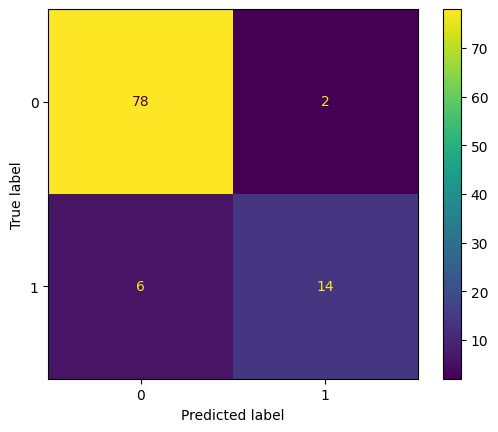

Confusion Matrix for class 4:
[[74  6]
 [ 4 16]]


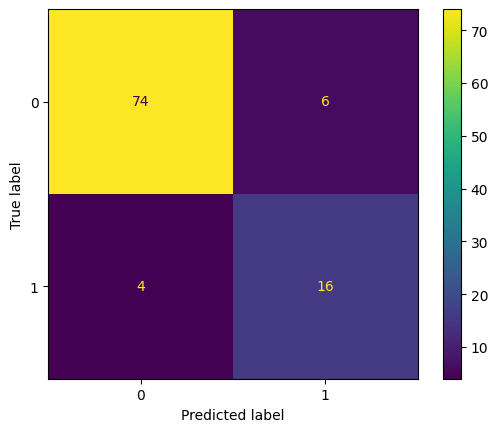

Precision: [0.68181818 0.89473684 0.75       0.875      0.72727273]
Recall: [0.78947368 0.5862069  0.75       0.7        0.8       ]
F1-score: [0.73170732 0.70833333 0.75       0.77777778 0.76190476]

Test Accuracy: 90.20%


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prepare test data loader
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Set all model layers to evaluation mode
embedding.eval()
conv.eval()
pool.eval()
lstm.eval()
dropout.eval()
fc.eval()
sigmoid.eval()

test_preds = []
test_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        embedded = embedding(X_batch)
        embedded = embedded.permute(0, 2, 1)
        conv_out = conv(embedded)
        pooled = pool(conv_out)
        pooled = pooled.permute(0, 2, 1)

        lstm_out, (hidden, cell) = lstm(pooled)
        hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        dropped = dropout(hidden_cat)
        output = fc(dropped)
        output = sigmoid(output)

        preds = (output > 0.5).int()

        test_preds.append(preds.cpu().numpy())
        test_targets.append(y_batch.cpu().numpy())

test_preds = np.vstack(test_preds)
test_targets = np.vstack(test_targets)

num_classes = test_targets.shape[1]

for i in range(num_classes):
    cm = confusion_matrix(test_targets[:, i], test_preds[:, i])
    print(f"Confusion Matrix for class {i}:")
    print(cm)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot()
    plt.show()

precision, recall, f1, _ = precision_recall_fscore_support(test_targets, test_preds, average=None)

print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-score: {f1}\n")

accuracy = np.mean(test_preds == test_targets)
print(f"Test Accuracy: {accuracy * 100:.2f}%")
